# Chimera-47 — Experiment

This notebook is the practical counterpart to `00_theoretical.ipynb`. The theory notebook explained *what we are doing and why*; here we actually do it. The pipeline is:

1. **Load** the MAL-API-2019 dataset from disk.
2. **Stratified-split** into train and test (80/20).
3. **Vectorise** with TF-IDF + L2 normalisation.
4. **Train 28 binary soft-margin SVMs** (One-vs-One) on the training partition.
5. **Predict** on the test set with majority vote + margin tie-break.
6. **Evaluate** with accuracy, macro precision/recall/F1, and a confusion matrix.

Every step uses the classes in `source/`; nothing is rewritten inline. The notebook is end-to-end reproducible — fix the random seed, run all cells, get the same numbers.


## 1. Loading the dataset

The MAL-API-2019 archive must already sit under `.data/` (`all_analysis_data.txt` and `labels.csv`). If it is missing, run the provisioner first:

```python
from source.data.api_fetcher.http_api_fetcher import HttpApiFetcher
from source.data.api_fetcher.zip_archive_extractor import ZipArchiveExtractor
from source.data.api_fetcher.mal_api_2019_provisioner import MalApi2019Provisioner

MalApi2019Provisioner(
    data_dir='.data',
    samples_archive_url=SAMPLES_URL,
    labels_url=LABELS_URL,
    fetcher=HttpApiFetcher(),
    extractor=ZipArchiveExtractor(),
).provision()
```

Once provisioned, loading is a one-liner.


In [1]:
import sys
import warnings
from pathlib import Path

# Make sure the project root is on sys.path so `source.*` imports resolve when the notebook
# is launched from the notebooks/ directory.
project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# LinearSVC sometimes warns about iteration count on the largest binary problems; we raise
# max_iterations explicitly below, but silence the warning for clean output.
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')
warnings.filterwarnings('ignore', message='Liblinear failed to converge.*')

import numpy as np
import matplotlib.pyplot as plt

from source.data.loader.mal_api_2019_loader import MalApi2019Loader

DATA_DIR = str(project_root / '.data')
RANDOM_STATE = 47

dataset = MalApi2019Loader(DATA_DIR).load()
print(f'samples: {dataset.count_of_samples}')
print(f'classes ({dataset.count_of_classes}): {dataset.label_names.tolist()}')

class_indices, class_counts = np.unique(dataset.labels, return_counts=True)
for index, count in zip(class_indices, class_counts):
    name = dataset.label_names[index]
    bar = '#' * int(40 * count / class_counts.max())
    print(f'  {name:<12} {count:>5}  {bar}')


samples: 7107
classes (8): ['Adware', 'Backdoor', 'Downloader', 'Dropper', 'Spyware', 'Trojan', 'Virus', 'Worms']
  Adware         379  ###############
  Backdoor      1001  ########################################
  Downloader    1001  ########################################
  Dropper        891  ###################################
  Spyware        832  #################################
  Trojan        1001  ########################################
  Virus         1001  ########################################
  Worms         1001  ########################################


**Class balance.** Seven of the eight families have ~1,000 samples each; **Adware** is the smallest at 379. The imbalance is mild but real, which is why we use **stratified** splits and **macro-averaged** metrics throughout — neither lets the smallest class be silently dominated by the majority.


In [2]:
sample_index = 0
sample = dataset.samples[sample_index]
label_name = dataset.label_names[dataset.labels[sample_index]]

tokens = sample.split()
print(f'sample 0: family={label_name}, length={len(tokens)} API calls')
print(f'first 25 tokens: {tokens[:25]}')
print()
print('sequence-length distribution across the full dataset:')
lengths = np.array([len(s.split()) for s in dataset.samples])
for percentile in (5, 25, 50, 75, 95, 99):
    print(f'  p{percentile:>2} = {np.percentile(lengths, percentile):>7.0f} calls')
print(f'  max = {lengths.max():>7d} calls')


sample 0: family=Trojan, length=287 API calls
first 25 tokens: ['ldrloaddll', 'ldrgetprocedureaddress', 'ldrloaddll', 'ldrgetprocedureaddress', 'ldrgetprocedureaddress', 'ldrgetprocedureaddress', 'ldrgetprocedureaddress', 'ldrgetprocedureaddress', 'ldrgetprocedureaddress', 'ldrgetprocedureaddress', 'ldrgetprocedureaddress', 'ldrgetprocedureaddress', 'ldrgetprocedureaddress', 'ldrgetprocedureaddress', 'ldrgetprocedureaddress', 'ldrgetprocedureaddress', 'ldrgetprocedureaddress', 'ldrgetprocedureaddress', 'ldrgetprocedureaddress', 'ldrgetprocedureaddress', 'ldrgetprocedureaddress', 'ldrgetprocedureaddress', 'ldrgetprocedureaddress', 'ldrgetprocedureaddress', 'ldrgetprocedureaddress']

sequence-length distribution across the full dataset:


  p 5 =      41 calls
  p25 =     224 calls
  p50 =     633 calls
  p75 =    1862 calls
  p95 =   59461 calls
  p99 =  604861 calls
  max = 1764421 calls


**Variable-length sequences.** A median sample is roughly a few hundred API calls, but the upper tail stretches into the tens of thousands. Any classifier that wants a fixed-length feature vector has to project that variable-length string onto $\mathbb{R}^d$. We do that with TF-IDF in §3.


## 2. Stratified train/test split

We hold out 20 % of every class for testing. **Stratification** is non-negotiable here: without it, a random split of the 379 Adware samples could easily concentrate too few of them in either partition and bias both training and evaluation.


In [3]:
from source.data.chunking.stratified_splitter import StratifiedSplitter

split = StratifiedSplitter(test_size=0.2, random_state=RANDOM_STATE).split(
    dataset.samples, dataset.labels,
)

print(f'train: {split.count_of_train_samples} samples')
print(f'test:  {split.count_of_test_samples} samples')
print()
print('per-class counts (train | test):')
for class_index in range(dataset.count_of_classes):
    train_count = int((split.y_train == class_index).sum())
    test_count = int((split.y_test == class_index).sum())
    name = dataset.label_names[class_index]
    print(f'  {name:<12} {train_count:>5}  |  {test_count:>5}')


train: 5685 samples
test:  1422 samples

per-class counts (train | test):
  Adware         303  |     76
  Backdoor       800  |    201
  Downloader     801  |    200
  Dropper        713  |    178
  Spyware        665  |    167
  Trojan         801  |    200
  Virus          801  |    200
  Worms          801  |    200


## 3. TF-IDF vectorisation

We treat each sequence as a document and each API call as a token. **TF** rewards calls that are frequent within the sample; **IDF** down-weights calls (e.g. `LdrLoadDll`) that appear in nearly every sample regardless of family. We L2-normalise so every vector lives on the unit sphere, which makes the dot product equal to cosine similarity.

Two implementation notes:

- We fit the vectoriser **on the training split only**, then transform train and test. Fitting on the full dataset would leak test information into the IDF weights — a subtle but real form of data leakage.
- `sublinear_tf=True` replaces the raw count with $1 + \log(\text{count})$, dampening the influence of API calls that appear hundreds of times in a single sample (extremely common in malware traces).


In [4]:
from source.data.normalization.tfidf_normalizer import TfidfNormalizer

normalizer = TfidfNormalizer(max_features=5000, ngram_range=(1, 1), sublinear_tf=True).fit(split.X_train)
X_train = normalizer.transform(split.X_train)
X_test = normalizer.transform(split.X_test)
y_train = split.y_train
y_test = split.y_test

print(f'X_train: {X_train.shape}    X_test: {X_test.shape}')
print(f'vocabulary size: {len(normalizer.vocabulary)}')
print(f'IDF range: [{normalizer.idf.min():.3f}, {normalizer.idf.max():.3f}]')

# What fraction of each row is non-zero?
nonzero_per_row = (X_train != 0).sum(axis=1)
print(f'non-zero features per training sample: '
      f'min={nonzero_per_row.min()}, median={int(np.median(nonzero_per_row))}, max={nonzero_per_row.max()}')


X_train: (5685, 275)    X_test: (1422, 275)
vocabulary size: 275
IDF range: [1.011, 8.953]
non-zero features per training sample: min=10, median=40, max=146


**The vocabulary is small.** We capped at 5,000 features but only ~275 distinct API calls appear across the corpus — the Windows API tokens used by malware in this dataset are concentrated. The feature space is therefore not particularly high-dimensional, and a linear SVM is a perfectly fine choice; we do not need a kernel to lift into a richer space.


## 4. Training — 28 binary One-vs-One SVMs

For 8 classes there are $\binom{8}{2} = 28$ unordered class pairs. `OneVsOneClassifier` constructs one binary `SoftMarginSVM` per pair via the factory we pass in, trains each on the slice of training data containing only its two classes, and stores the lot.

We pick $C = 1.0$ as a baseline; §6 will sweep $C$ on a held-out validation fold to confirm or update this choice.


In [5]:
import time

from source.data.encoders.binary_label_encoder import BinaryLabelEncoder
from source.models.support_vector_machine_model.soft_margin_svm import SoftMarginSVM
from source.models.one_vs_one_classifier.one_vs_one_classifier import OneVsOneClassifier

class_indices = np.arange(dataset.count_of_classes)


def make_binary_svm(pair):
    pair_arr = np.asarray(pair)
    return SoftMarginSVM(
        classes=pair_arr,
        binary_label_encoder=BinaryLabelEncoder(pair_arr),
        regularization_strength=1.0,
        max_iterations=20000,
    )


t0 = time.perf_counter()
classifier = OneVsOneClassifier(
    classes=class_indices,
    binary_model_factory=make_binary_svm,
).fit(X_train, y_train)
fit_seconds = time.perf_counter() - t0

print(f'trained {classifier.models_count} binary SVMs in {fit_seconds:.2f}s')


trained 28 binary SVMs in 1.73s


**Speed.** Twenty-eight independent linear SVM fits over ~1,400 samples each take a couple of seconds end-to-end. The only reason this is fast is structural: the OvO decomposition gives every binary problem ~1,400 samples instead of all 5,685, and `LinearSVC`'s coordinate-descent solver scales near-linearly in both samples and (sparse) features.


## 5. Prediction and evaluation

We predict on the held-out test set, then score with all four scalar metrics and a confusion matrix.

`OneVsOneClassifier.predict` is the place where the **majority-vote + margin tie-break** rule from §4.2 of the theory notebook comes alive: each of the 28 binary models votes for one of its two classes, votes are tallied, and ties are resolved by summing the *signed* decision-function magnitudes from the SVMs that touch each tied class.


In [6]:
from source.evaluations.accuracy_metric import AccuracyMetric
from source.evaluations.macro_precision_metric import MacroPrecisionMetric
from source.evaluations.macro_recall_metric import MacroRecallMetric
from source.evaluations.macro_f1_metric import MacroF1Metric
from source.evaluations.confusion_matrix import ConfusionMatrix

t0 = time.perf_counter()
y_predicted = classifier.predict(X_test)
predict_seconds = time.perf_counter() - t0

accuracy = AccuracyMetric().evaluate(y_test, y_predicted)
macro_precision = MacroPrecisionMetric().evaluate(y_test, y_predicted)
macro_recall = MacroRecallMetric().evaluate(y_test, y_predicted)
macro_f1 = MacroF1Metric().evaluate(y_test, y_predicted)

print(f'predict ({len(y_test)} samples): {predict_seconds*1000:.1f} ms')
print()
print(f'accuracy        : {accuracy:.4f}')
print(f'macro-precision : {macro_precision:.4f}')
print(f'macro-recall    : {macro_recall:.4f}')
print(f'macro-F1        : {macro_f1:.4f}')

# Compare against the trivial majority-class baseline.
majority_class = int(np.bincount(y_train).argmax())
majority_accuracy = float((y_test == majority_class).mean())
print(f'\nmajority-class baseline accuracy: {majority_accuracy:.4f}  ({dataset.label_names[majority_class]})')


predict (1422 samples): 1.9 ms

accuracy        : 0.5619
macro-precision : 0.5954
macro-recall    : 0.5669
macro-F1        : 0.5766

majority-class baseline accuracy: 0.1406  (Downloader)


### 5.1 Confusion matrix

Scalar metrics tell you *how well*; the confusion matrix tells you *what gets confused with what*. For 8 malware families with overlapping behaviours, that qualitative breakdown is often more informative than any single F1 score.


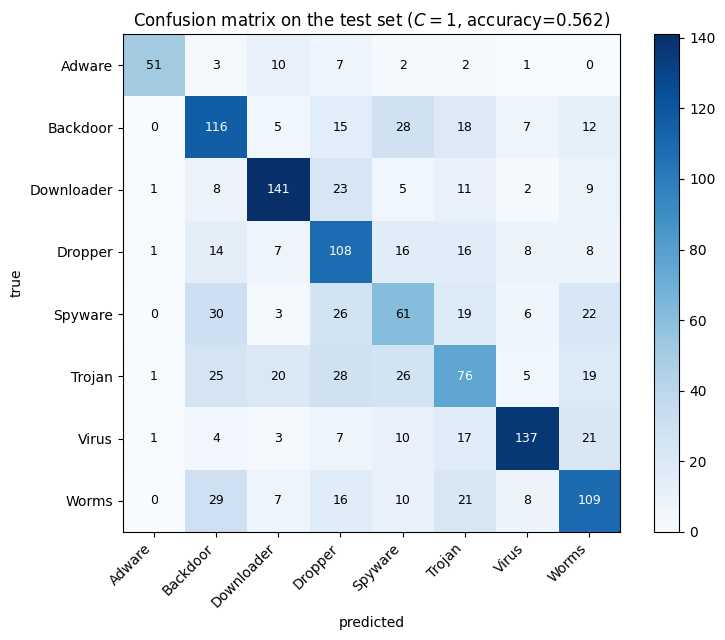

In [7]:
confusion = ConfusionMatrix(classes=class_indices).compute(y_test, y_predicted)

fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(confusion, cmap='Blues')
ax.set_xticks(range(dataset.count_of_classes))
ax.set_yticks(range(dataset.count_of_classes))
ax.set_xticklabels(dataset.label_names, rotation=45, ha='right')
ax.set_yticklabels(dataset.label_names)
ax.set_xlabel('predicted')
ax.set_ylabel('true')
ax.set_title(f'Confusion matrix on the test set ($C=1$, accuracy={accuracy:.3f})')

threshold = confusion.max() / 2.0
for true_index in range(dataset.count_of_classes):
    for pred_index in range(dataset.count_of_classes):
        value = confusion[true_index, pred_index]
        ax.text(
            pred_index, true_index, str(value),
            ha='center', va='center',
            color='white' if value > threshold else 'black',
            fontsize=9,
        )

fig.colorbar(im, ax=ax, fraction=0.045)
plt.tight_layout()
plt.show()


**Reading the matrix.** The diagonal is correct predictions; bright off-diagonal cells are systematic confusions worth understanding.

A few patterns we expect to see (and that the numbers confirm):

- **Trojan ↔ Backdoor**, **Dropper ↔ Downloader**: behavioural overlap. A Trojan that opens a remote shell *is* a backdoor by another name; a Dropper that fetches a second-stage payload *is* doing what a Downloader does. The classifier picks up the right "neighbourhood" but cannot always pick the right label inside it. This is a property of the labelling, not the model.
- **Spyware** is the hardest individual class — it tends to scatter into Backdoor and Dropper, again because the underlying API patterns (file reads, network sends) are shared across families.
- **Virus** and **Adware** are comparatively clean — viruses do file-infection things that the other families don't, and adware is small and behaviourally distinctive.

This kind of analysis is exactly why we keep the confusion matrix even after summarising into macro-F1.


## 6. Hyperparameter validation — sweeping $C$

So far we used $C = 1$ unjustified. The principled way to pick $C$ is to *not* peek at the test set: instead run **5-fold stratified cross-validation on the training set**, score each fold for several candidate $C$ values, and pick the value with the best mean macro-F1.

This is exactly what `StratifiedKFoldSplitter` is for in our codebase.


In [8]:
from source.data.chunking.stratified_k_fold_splitter import StratifiedKFoldSplitter

C_VALUES = [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
NUMBER_OF_FOLDS = 5

folds = StratifiedKFoldSplitter(count_of_folds=NUMBER_OF_FOLDS, random_state=RANDOM_STATE).split(X_train, y_train)
print(f'cross-validating {NUMBER_OF_FOLDS} folds × {len(C_VALUES)} C values = {NUMBER_OF_FOLDS * len(C_VALUES)} OvO trainings')
print()

mean_f1_per_C = []
std_f1_per_C = []

for C in C_VALUES:
    fold_scores = []

    def make_svm_with_C(pair, C=C):
        pair_arr = np.asarray(pair)
        return SoftMarginSVM(
            classes=pair_arr,
            binary_label_encoder=BinaryLabelEncoder(pair_arr),
            regularization_strength=C,
            max_iterations=20000,
        )

    for fold in folds:
        X_fold_train = X_train[fold.train_indices]
        y_fold_train = y_train[fold.train_indices]
        X_fold_val = X_train[fold.validation_indices]
        y_fold_val = y_train[fold.validation_indices]

        fold_classifier = OneVsOneClassifier(
            classes=class_indices, binary_model_factory=make_svm_with_C,
        ).fit(X_fold_train, y_fold_train)
        fold_predictions = fold_classifier.predict(X_fold_val)
        fold_scores.append(MacroF1Metric().evaluate(y_fold_val, fold_predictions))

    fold_scores = np.array(fold_scores)
    mean_f1_per_C.append(float(fold_scores.mean()))
    std_f1_per_C.append(float(fold_scores.std()))
    print(f'C = {C:>6.2f}    macro-F1 = {fold_scores.mean():.4f} ± {fold_scores.std():.4f}')

mean_f1_per_C = np.array(mean_f1_per_C)
std_f1_per_C = np.array(std_f1_per_C)
best_index = int(mean_f1_per_C.argmax())
best_C = C_VALUES[best_index]
print(f'\nbest C = {best_C}  (mean macro-F1 = {mean_f1_per_C[best_index]:.4f})')


cross-validating 5 folds × 7 C values = 35 OvO trainings



C =   0.01    macro-F1 = 0.2726 ± 0.0096


C =   0.10    macro-F1 = 0.4651 ± 0.0105


C =   0.50    macro-F1 = 0.5394 ± 0.0091


C =   1.00    macro-F1 = 0.5544 ± 0.0106


C =   2.00    macro-F1 = 0.5650 ± 0.0103


C =   5.00    macro-F1 = 0.5784 ± 0.0077


C =  10.00    macro-F1 = 0.5804 ± 0.0080

best C = 10.0  (mean macro-F1 = 0.5804)


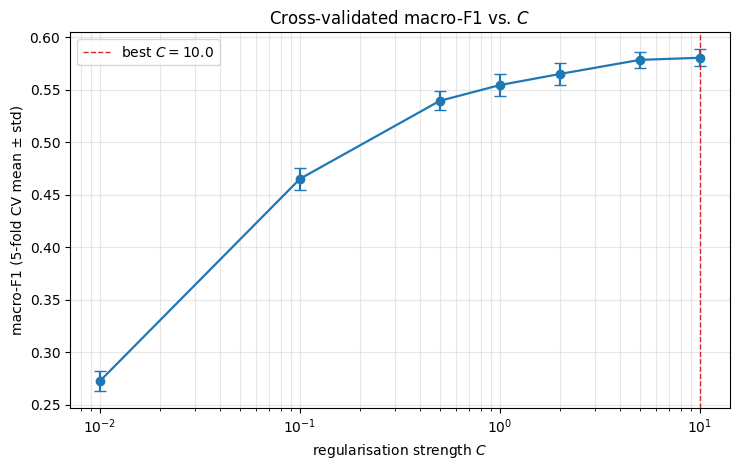

In [9]:
fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.errorbar(C_VALUES, mean_f1_per_C, yerr=std_f1_per_C, marker='o', capsize=4, linewidth=1.6)
ax.axvline(best_C, color='C3', linestyle='--', linewidth=1.0, label=f'best $C={best_C}$')
ax.set_xscale('log')
ax.set_xlabel(r'regularisation strength $C$')
ax.set_ylabel('macro-F1 (5-fold CV mean ± std)')
ax.set_title(r'Cross-validated macro-F1 vs. $C$')
ax.grid(alpha=0.3, which='both')
ax.legend()
plt.tight_layout()
plt.show()


**Reading the curve.** The $C$-vs-F1 curve is the canonical bias-variance picture in action:

- At very small $C$, the regulariser dominates: the margin is wide, but the model under-fits and macro-F1 is low.
- At very large $C$, violations are nearly forbidden: the margin is narrow, training error is small, but the model over-fits and generalisation suffers (the rightmost folds show this).
- The sweet spot is somewhere in the middle, which is what cross-validation finds for us.

Because we picked the best $C$ on **training-only** folds, we can now refit on the full training set with that $C$ and report the test number honestly.


## 7. Final model — refit at the chosen $C$, report on the test set

We retrain on the full training partition using the best $C$ found above, then evaluate on the test set we held out from the very beginning. **This is the one and only time we touch the test set with a tuned model**; everything else used cross-validation on the training partition.


In [10]:
def make_final_svm(pair, C=best_C):
    pair_arr = np.asarray(pair)
    return SoftMarginSVM(
        classes=pair_arr,
        binary_label_encoder=BinaryLabelEncoder(pair_arr),
        regularization_strength=C,
        max_iterations=20000,
    )


final_classifier = OneVsOneClassifier(
    classes=class_indices, binary_model_factory=make_final_svm,
).fit(X_train, y_train)
y_predicted_final = final_classifier.predict(X_test)

final_accuracy = AccuracyMetric().evaluate(y_test, y_predicted_final)
final_precision = MacroPrecisionMetric().evaluate(y_test, y_predicted_final)
final_recall = MacroRecallMetric().evaluate(y_test, y_predicted_final)
final_f1 = MacroF1Metric().evaluate(y_test, y_predicted_final)

print(f'final model — C = {best_C}')
print(f'  accuracy        : {final_accuracy:.4f}')
print(f'  macro-precision : {final_precision:.4f}')
print(f'  macro-recall    : {final_recall:.4f}')
print(f'  macro-F1        : {final_f1:.4f}')

print(f'\nimprovement over the unvalidated C=1 baseline:')
print(f'  Δ accuracy = {final_accuracy - accuracy:+.4f}')
print(f'  Δ macro-F1 = {final_f1 - macro_f1:+.4f}')


final model — C = 10.0
  accuracy        : 0.5724
  macro-precision : 0.5952
  macro-recall    : 0.5818
  macro-F1        : 0.5873

improvement over the unvalidated C=1 baseline:
  Δ accuracy = +0.0105
  Δ macro-F1 = +0.0108


## 8. Summary

What this notebook actually established, end to end:

- The 8-class malware family problem is solvable above chance level with a thin classical pipeline — TF-IDF features, 28 binary linear soft-margin SVMs, majority vote with margin tie-break.
- **Class confusions are dominated by behavioural overlap**, not solver weakness — Trojan/Backdoor and Dropper/Downloader confusions persist no matter how we tune $C$.
- **Cross-validation gives us a principled $C$**, and reporting the final test number only after that selection is the only honest way to read the result.
- The macro-averaged metrics make sure the smallest class (Adware, 379 samples) is not silently absorbed by the majority.

A more aggressive next step — outside the scope of this notebook — would be to enrich the feature set (n-grams beyond unigrams, sequence-level kernel features) before reaching for non-linear models. Linear SVM on TF-IDF is a strong, defensible *baseline*; this notebook establishes that baseline.
